# Fourier Captured Energy

This module tests the captured energy API, a core component of the functional Principal Component Analysis (fPCA) objective. The underlying mechanism involves pulling back a function through a learned isometry to maximize its expected Fourier coefficients under the measure $\nu$. This effectively concentrates the function's energy within the lowest frequencies.

A straightforward implementation relies on Monte Carlo integration. By sampling a batch of frequency indices from $\nu$ and averaging their inner products with the pulled-back function, we obtain an unbiased estimator of the captured energy. While this grid-free method naturally accommodates irregular domains, it inherently suffers from high variance and demands substantial sample complexity.

A more efficient alternative is to pull back the function and apply the Non-Uniform Fast Fourier Transform (NUFFT) to map the representation into the frequency domain. Assuming aliasing effects are negligible, the captured energy can then be quickly computed via a direct dot product between these transformed coefficients and the corresponding probability weights on the frequency grid.

Let's get the basic imports out of the way:

In [1]:
%load_ext autoreload
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

First, sample a high frequency and low frequency signal, the aim is to compare their captured energy down the line with different methods:

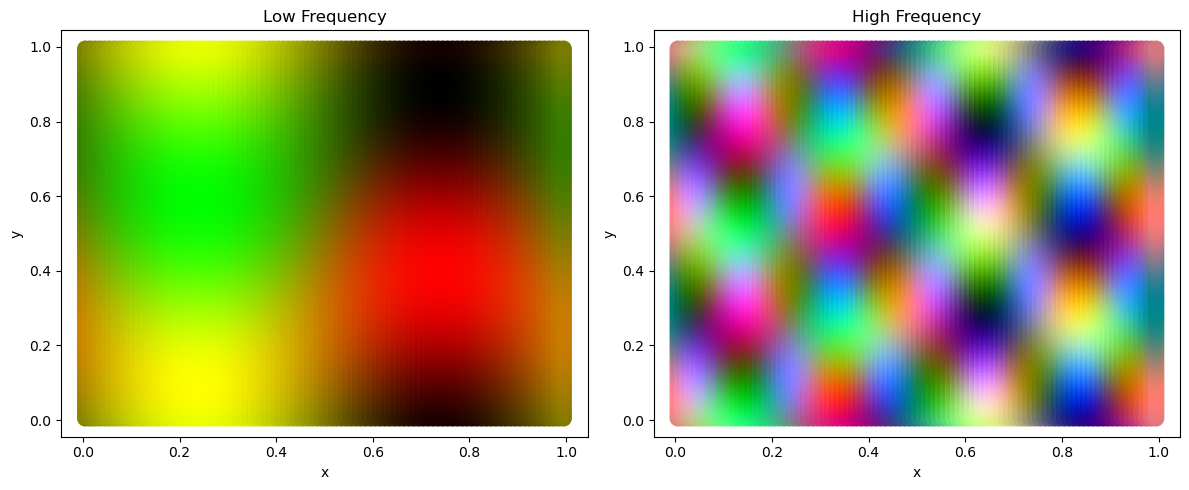

In [3]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary
from infidictionary.domain_samplers import SquareSampler

coords = SquareSampler(stratified=True, add_noise=False).sample(100).to(device)
fourier_basis = FourierDictionary(
    domain_dim=2,
    num_channels=3,
    p=0.3, 
    # distribution_type="zeta",
    # distribution_kwargs={"a": 1.5},
)
# Indices are (k1, k2, c) — last column is the channel index (0=R, 1=G, 2=B)
high_freq_indices = torch.tensor([
    [3,  2,  0],   # R
    [-2, 2,  1],   # G
    [-5, -2, 2],   # B
    [3,  -2, 0],   # R
])
low_freq_indices = torch.tensor([
    [0,  -1, 0],   # R
    [-1,  0, 1],   # G
    [0,   0, 2],   # B
    [-1,  1, 0],   # R
])

low_frequency_signal = fourier_basis.get_atoms(
    coords.to(device), low_freq_indices.to(device),
).sum(dim=0)  # (N, 3)
high_frequency_signal = fourier_basis.get_atoms(
    coords.to(device), high_freq_indices.to(device),
).sum(dim=0)  # (N, 3)

def to_rgb(signal):
    """Normalise each channel to [0,1] independently and return (N,3) float array."""
    s = signal.detach().cpu().float().numpy()
    for c in range(3):
        lo, hi = s[:, c].min(), s[:, c].max()
        s[:, c] = (s[:, c] - lo) / (hi - lo + 1e-8)
    return s

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, title, signal in zip(axes,
                              ['Low Frequency', 'High Frequency'],
                              [low_frequency_signal, high_frequency_signal]):
    ax.scatter(
        coords[:, 0].detach().cpu(),
        coords[:, 1].detach().cpu(),
        c=to_rgb(signal),
        s=120,
    )
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
plt.tight_layout()
plt.show()


In [4]:
TOTAL = 1000000
indices = fourier_basis.sample_indices(TOTAL)
# count the number of times each index in low_freq_indices is sampled
counts = torch.zeros(low_freq_indices.shape[0], device=device)
for i, idx in enumerate(low_freq_indices):
    counts[i] = (indices == idx).all(dim=1).sum()
print("Low frequency indices and their estimated pmfs:")
for idx, count in zip(low_freq_indices, counts):
    print(f"Index: {idx.cpu().numpy()}, Estimated PMF: {count.item()/TOTAL:.6f}")


Low frequency indices and their estimated pmfs:
Index: [ 0 -1  0], Estimated PMF: 0.008723
Index: [-1  0  1], Estimated PMF: 0.008559
Index: [0 0 2], Estimated PMF: 0.099667
Index: [-1  1  0], Estimated PMF: 0.008832


In [5]:

fourier_basis.sample_indices(20)

tensor([[  1,   0,   0],
        [ -1,   0,   0],
        [  1,  -1,   0],
        [  0,   0,   0],
        [ -1,   2,   2],
        [  2,  -3,   0],
        [ -3,  -3,   0],
        [  0,   0,   2],
        [ 10, -11,   0],
        [ -2,   2,   2],
        [  1,  -5,   2],
        [  5,   5,   0],
        [ -1,  -1,   2],
        [  4,   5,   2],
        [  4,  -6,   2],
        [  3,   2,   1],
        [ -1,   1,   0],
        [ -2,   2,   2],
        [  4,  -7,   2],
        [  0,   0,   0]])

In [10]:
nyquist = 128
pmfs = fourier_basis.compute_grid_probas(nyquist=nyquist).to(coords.device) # (nyquist+1, nyquist+1  )
for idx in low_freq_indices:
    print(f"Index: {idx.cpu().numpy()}, Estimated PMF: {pmfs[idx[0]+nyquist, idx[1]+nyquist].item():.5f}")

Index: [ 0 -1  0], Estimated PMF: 0.03150
Index: [-1  0  1], Estimated PMF: 0.03150
Index: [0 0 2], Estimated PMF: 0.09000
Index: [-1  1  0], Estimated PMF: 0.01102


In [6]:
all_indices = fourier_basis.get_truncated_indices(2)
probas = fourier_basis.get_index_pmfs(all_indices)
for i in range(len(all_indices)):
    print(f"Index: {all_indices[i]}, Probability: {probas[i]}")

Index: tensor([-1, -1,  0]), Probability: 0.008750000037252903
Index: tensor([-1, -1,  1]), Probability: 0.008750000037252903
Index: tensor([-1, -1,  2]), Probability: 0.008750000037252903
Index: tensor([-1,  0,  0]), Probability: 0.008750000037252903
Index: tensor([-1,  0,  1]), Probability: 0.008750000037252903
Index: tensor([-1,  0,  2]), Probability: 0.008750000037252903
Index: tensor([-1,  1,  0]), Probability: 0.008750000037252903
Index: tensor([-1,  1,  1]), Probability: 0.008750000037252903
Index: tensor([-1,  1,  2]), Probability: 0.008750000037252903
Index: tensor([ 0, -1,  0]), Probability: 0.008750000037252903
Index: tensor([ 0, -1,  1]), Probability: 0.008750000037252903
Index: tensor([ 0, -1,  2]), Probability: 0.008750000037252903
Index: tensor([0, 0, 0]), Probability: 0.10000000149011612
Index: tensor([0, 0, 1]), Probability: 0.10000000149011612
Index: tensor([0, 0, 2]), Probability: 0.10000000149011612
Index: tensor([0, 1, 0]), Probability: 0.008750000037252903
Index: 

In [10]:
indices = fourier_basis.get_high_probability_indices(0.0005)
print(len(indices))
# for i in range(len(indices)):
#     print(f"Index: {indices[i]}, Probability: {fourier_basis.get_index_pmfs(indices[i:i+1]).item():.5f}")

243


Next, we estimate the captured energy via Monte Carlo integration by sampling a large batch of Fourier basis functions and computing their Hilbert-space inner products. In expectation, the low-frequency signal will yield a greater captured energy than the high-frequency counterpart. However, the high variance inherent to this estimator means that the empirical distributions of the captured energies will exhibit substantial overlap when plotted as histograms:

100%|██████████| 1000/1000 [00:46<00:00, 21.34it/s]


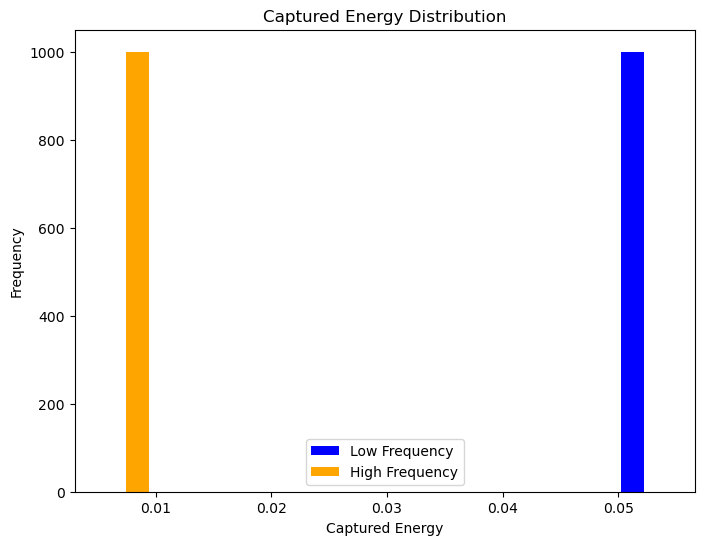

In [13]:

all_signals = torch.stack([low_frequency_signal, high_frequency_signal])  # (2, N, 3)
all_captured_energies = []
batch_size = 64
n_draws = 1000

for _ in tqdm(range(n_draws)):
    captured_energy = fourier_basis.monte_carlo_captured_energy(
        coords=coords,
        logabsdet=torch.zeros(coords.shape[0], device=device),
        values=all_signals,  # (B, N, C)
        num_tail_samples=batch_size,
        tail_probability=1e-4,
    )
    all_captured_energies.append(captured_energy.cpu())
all_captured_energies = torch.stack(all_captured_energies)  # (num_trials, B)
plt.figure(figsize=(8, 6))
plt.hist(all_captured_energies, color=['blue', 'orange'], label=['Low Frequency', 'High Frequency'])
plt.title('Captured Energy Distribution')
plt.xlabel('Captured Energy')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Next, we can try the method with NUFFT to compare the results:

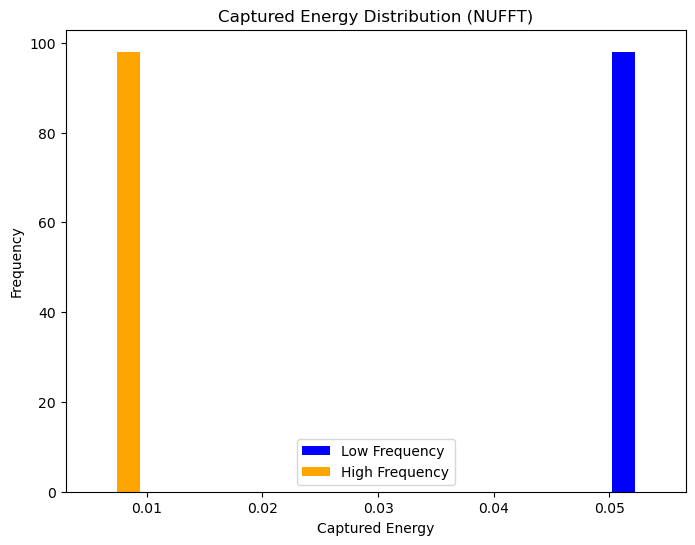

In [17]:
all_signals = torch.stack([low_frequency_signal, high_frequency_signal])  # (2, N, 3)
all_captured_energies = []
all_dfts = []
for nyquist_freq in range(32, 130):
    captured_energy, dft, all_probas = fourier_basis.nufft_captured_energy(
        coords=coords.to(device),
        logabsdet=torch.zeros(coords.shape[0], device=device),
        values=all_signals.to(device),  # (B, N, C)
        nyquist=nyquist_freq,
        return_dft=True,
    )
    all_dfts.append(dft.detach().cpu())
    all_captured_energies.append(captured_energy.detach().cpu())
all_captured_energies = torch.stack(all_captured_energies)  # (num_nyquist, B)
plt.figure(figsize=(8, 6))
plt.hist(all_captured_energies.numpy(), color=['blue', 'orange'], label=['Low Frequency', 'High Frequency'])
plt.title('Captured Energy Distribution (NUFFT)')
plt.xlabel('Captured Energy')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Run the following to check if Parseval's theorem holds:

In [16]:
# Parseval: sum_{k,c} |F_c(k)|² = (1/N) * sum_n ||f(x_n)||²  (sum over C, mean over N)
dft_energy = (all_dfts[0][0].abs() ** 2).sum().float()
signal_energy = (all_signals[0] ** 2).sum(dim=-1).mean().float()
assert torch.isclose(dft_energy, signal_energy, atol=1e-5), f"Parseval's theorem is violated: {dft_energy} != {signal_energy}"
